# Neural machine translation: LSTM only

In this demo, we build a English-French seq2seq translation model. Some of the key implementation details are:

1. **Subword tokenization** - Word-level tokenization creates massive vocabularies (50K+ words) and can't handle unseen words. We use SentencePiece to keep vocabulary manageable (~8K tokens) while handling any input.

2. **Real training data** - We use 10,000 sentence pairs from the OPUS-100 English-French corpus instead of 15 hand-crafted phrases.

3. **Bidirectional encoder** - Capture context from both directions for better source understanding.

### References

The encoder-decoder architecture for neural machine translation was introduced in:

> Sutskever, I., Vinyals, O., & Le, Q. V. (2014). **Sequence to sequence learning with neural networks.** *Advances in Neural Information Processing Systems, 27.* https://arxiv.org/abs/1409.3215

The OPUS-100 dataset used in this activity:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## Notebook set-up

**Note**: This notebook uses a few dependencies that may not be commonly found in development environments (they are not included in the course deeplearning container) I think this should colver it:

`pip install sacrebleu sacremoses sentencepiece transformers`

### Imports

In [ ]:
# Suppress TensorFlow warnings and select GPU
import logging
import os

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '1' # Select GPU, 0 for GPU 1, etc.

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras model components
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Bidirectional, Concatenate

### Configuration

In [ ]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Set event level output filter for TensorFlow
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

## 1. Prepare assets

Using the OPUS-100 English-French translation corpus from Hugging Face datasets with subword tokenization (SentencePiece). Subword tokenization is essential for NMT (Neural Machine Translation) because it:
- Keeps vocabulary manageable (~8K tokens vs 50K+ words)
- Handles rare/unseen words by breaking them into known subwords
- Shares subword units across related words (e.g., "play", "playing", "played")

### 1.1. Load tokenizer

In [3]:
# Load pre-trained subword tokenizer (SentencePiece)
# MarianTokenizer is specifically designed for the Helsinki-NLP translation models
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

print(f'Tokenizer vocabulary size: {tokenizer.vocab_size}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

# Example of subword tokenization
example = 'The neural network learned representations'
tokens = tokenizer.tokenize(example)
print(f'\nExample tokenization:')
print(f'  Input: "{example}"')
print(f'  Tokens: {tokens}')

Tokenizer vocabulary size: 59514
Special tokens: {'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}

Example tokenization:
  Input: "The neural network learned representations"
  Tokens: ['▁The', '▁ne', 'ural', '▁network', '▁learned', '▁representations']


### 1.2. Load dataset

In [ ]:
# Load OPUS-100 English-French translation dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr')

# Extract translation pairs and filter by token length
pairs = []
MAX_SEQ_LENGTH = 20  # Maximum tokens per sentence

for item in dataset['train']:

    en_text = item['translation']['en'].strip()
    fr_text = item['translation']['fr'].strip()
    
    # Check token length using tokenize() to avoid truncation warnings
    en_tokens = tokenizer.tokenize(en_text)
    fr_tokens = tokenizer.tokenize(fr_text)
    
    if len(en_tokens) <= MAX_SEQ_LENGTH and len(fr_tokens) <= MAX_SEQ_LENGTH:
        pairs.append((en_text, fr_text))
    
    # Limit dataset size for reasonable training time
    if len(pairs) >= 100000:
        break

print(f'Loaded {len(pairs)} translation pairs')
print(f'\nSample pairs:')

for en, fr in pairs[1:5]:
    print()
    print(f'  EN: {en}')
    print(f'  FR: {fr}')

Loaded 100000 translation pairs

Sample pairs:
  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.

  EN: Did you find something?
  FR: Par ici !

  EN: Article 6
  FR: Article 6



In [5]:
# Tokenize all pairs using the subword tokenizer
# The tokenizer handles both English and French (it's a multilingual SentencePiece model)
MAX_ENCODER_LEN = 22  # Slightly larger than MAX_SEQ_LENGTH for special tokens
MAX_DECODER_LEN = 24

# Tokenize source (English) sentences
encoder_inputs = tokenizer(
    [pair[0] for pair in pairs],
    padding='max_length',
    truncation=True,
    max_length=MAX_ENCODER_LEN,
    return_tensors='np'
)

# Tokenize target (French) sentences
decoder_input_texts = [pair[1] for pair in pairs]

decoder_inputs = tokenizer(
    decoder_input_texts,
    padding='max_length',
    truncation=True,
    max_length=MAX_DECODER_LEN - 1,  # Leave room for BOS token
    return_tensors='np'
)

# Prepare encoder data
encoder_input_data = encoder_inputs['input_ids']

# CRITICAL: Decoder input must start with BOS token (we use pad_token_id)
# This aligns training with inference, where we also start with pad_token_id
# decoder_input: [BOS, tok1, tok2, ..., tokN, pad, pad...]
# decoder_target: [tok1, tok2, ..., tokN, EOS, pad, pad...]
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_input_data[:, 1:1 + raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Targets are the original tokens (what we want to predict after BOS)
decoder_target_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_target_data[:, :raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Model dimensions
num_samples = len(pairs)
num_tokens = tokenizer.vocab_size  # Same vocab for encoder and decoder
max_encoder_len = MAX_ENCODER_LEN
max_decoder_len = MAX_DECODER_LEN

print(f'Vocabulary size: {num_tokens}')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'Training samples: {num_samples}')
print(f'\nEncoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')

# Verify alignment: at position 0, input is BOS (pad), target is first real token
print(f'\nVerifying BOS alignment:')
print(f'  Decoder input[0, :5]:  {decoder_input_data[0, :5]} (first should be {tokenizer.pad_token_id} = BOS)')
print(f'  Decoder target[0, :5]: {decoder_target_data[0, :5]} (first real token)')

Vocabulary size: 59514
Max encoder length: 22
Max decoder length: 24
Training samples: 100000

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)

Verifying BOS alignment:
  Decoder input[0, :5]:  [59513    35   195   453    32] (first should be 59513 = BOS)
  Decoder target[0, :5]: [  35  195  453   32 6987] (first real token)


## 2. Model definitions

This section defines all model components needed for training and evaluation. We build:
1. **Training model**: The encoder-decoder architecture trained on parallel text
2. **Inference models**: Separate encoder and decoder for autoregressive translation
3. **Translation function**: Greedy decoding loop for generating translations
4. **BLEU callback**: Monitors translation quality during training

**Training architecture:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
         │                                                       │
         ▼                                                       ▼
   ┌─────────────┐                                        ┌─────────────┐
   │  Embedding  │                                        │  Embedding  │
   └──────┬──────┘                                        └──────┬──────┘
          │                                                      │
          ▼                                                      ▼
  ┌───────────────┐       Context vector [h, c]           ┌─────────────┐
  │ Bidirectional │ ────────────────────────────────────► │    LSTM     │
  │     LSTM      │       (concatenated states)           └──────┬──────┘
  └───────────────┘                                              │
                                                                 ▼
                                                          ┌─────────────┐
                                                          │    Dense    │
                                                          │  (softmax)  │
                                                          └──────┬──────┘
                                                                 │
                                                                 ▼
                                                           Output sequence
                                                                 │
                                                    ┌────────────┴────────────┐
                                                    ▼                         ▼
                                         Labels (shifted target)         Predictions
                                          "Bonjour monde </s>"       "Bonjour monde </s>"
                                                    │                         │
                                                    └─────────► Loss ◄────────┘
```

### 2.1. Training model

The training model uses teacher forcing: at each decoder step, it receives the ground truth previous token rather than its own prediction. This allows parallel computation of the entire output sequence but requires a different architecture for inference.

In [6]:
def build_bidirectional_model(latent_dim=256):
    '''Build encoder-decoder with bidirectional encoder.'''

    # Encoder with bidirectional LSTM
    encoder_inputs = Input(shape=(max_encoder_len,), name='encoder_input')
    encoder_embedding = Embedding(num_tokens, latent_dim, mask_zero=True, name='encoder_embedding')
    encoder_embedded = encoder_embedding(encoder_inputs)
    
    # Bidirectional LSTM encoder
    encoder_lstm = Bidirectional(
        LSTM(latent_dim, return_state=True, name='encoder_lstm'),
        name='bidirectional_encoder'
    )
    
    # Get outputs and states from bidirectional LSTM
    # Returns: outputs, forward_h, forward_c, backward_h, backward_c
    outputs, fwd_h, fwd_c, bwd_h, bwd_c = encoder_lstm(encoder_embedded)
    
    # Concatenate forward and backward states
    state_h = Concatenate(name='concat_h')([fwd_h, bwd_h])
    state_c = Concatenate(name='concat_c')([fwd_c, bwd_c])
    encoder_states = [state_h, state_c]
    
    # Decoder (note: latent_dim * 2 because of bidirectional concatenation)
    decoder_inputs = Input(shape=(max_decoder_len,), name='decoder_input')
    decoder_embedding = Embedding(num_tokens, latent_dim, mask_zero=True, name='decoder_embedding')
    decoder_embedded = decoder_embedding(decoder_inputs)
    decoder_lstm = LSTM(latent_dim * 2, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_embedded, initial_state=encoder_states)
    decoder_dense = Dense(num_tokens, activation='softmax', name='output')
    decoder_outputs = decoder_dense(decoder_outputs)
    
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

### 2.2. Inference models

During inference, we generate translations one token at a time using the decoder's own predictions. This requires restructuring the model into separate encoder and decoder components:
- The **encoder model** processes the input sentence once and returns the hidden states
- The **decoder model** takes a single token and the previous states, outputting the next token probabilities and updated states

This separation allows the autoregressive decoding loop where each predicted token feeds back as input.

In [ ]:
def build_inference_models(model, latent_dim=256):
    '''Build separate encoder and decoder models for inference.'''
    
    # ── Encoder inference model ──────────────────────────────────
    # Reuse trained layers from the full model
    encoder_input_layer = model.get_layer('encoder_input').input
    encoder_embedding_layer = model.get_layer('encoder_embedding')
    bidirectional_layer = model.get_layer('bidirectional_encoder')
    concat_h = model.get_layer('concat_h')
    concat_c = model.get_layer('concat_c')

    # Reconstruct encoder: input -> embedding -> BiLSTM -> concatenated states
    encoder_embedded = encoder_embedding_layer(encoder_input_layer)
    _, fwd_h, fwd_c, bwd_h, bwd_c = bidirectional_layer(encoder_embedded)
    state_h = concat_h([fwd_h, bwd_h])
    state_c = concat_c([fwd_c, bwd_c])
    
    # Encoder model: takes input sequence, outputs initial decoder states
    encoder_model = Model(encoder_input_layer, [state_h, state_c])

    # ── Decoder inference model ──────────────────────────────────
    # New inputs for states (fed from previous timestep or encoder)
    decoder_state_input_h = Input(shape=(latent_dim * 2,), name='decoder_state_h')
    decoder_state_input_c = Input(shape=(latent_dim * 2,), name='decoder_state_c')
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    # Single token input (shape=(1,) for one token at a time)
    decoder_input_layer = Input(shape=(1,), name='decoder_inf_input')
    
    # Reuse trained decoder layers
    decoder_embedding_layer = model.get_layer('decoder_embedding')
    decoder_lstm_layer = model.get_layer('decoder_lstm')
    decoder_dense_layer = model.get_layer('output')

    # Reconstruct decoder: token -> embedding -> LSTM -> softmax
    decoder_embedded = decoder_embedding_layer(decoder_input_layer)
    decoder_outputs, state_h, state_c = decoder_lstm_layer(
        decoder_embedded, initial_state=decoder_states_inputs
    )
    decoder_states = [state_h, state_c]
    decoder_outputs = decoder_dense_layer(decoder_outputs)

    # Decoder model: takes token + states, outputs probabilities + new states
    decoder_model = Model(
        [decoder_input_layer] + decoder_states_inputs,
        [decoder_outputs] + decoder_states
    )
    
    return encoder_model, decoder_model

### 2.3. Translation function

The translation function implements greedy decoding: at each step, it selects the token with the highest probability. While beam search would produce better translations, greedy decoding is faster and sufficient for monitoring training progress.

In [8]:
def translate(input_text, encoder_model, decoder_model):
    '''Translate English text to French using greedy decoding.'''
    
    # Tokenize and pad the input sentence
    input_tokens = tokenizer(
        input_text,
        padding='max_length',
        max_length=max_encoder_len,
        truncation=True,
        return_tensors='np'
    )['input_ids']
    
    # Encode: run encoder once to get initial states
    states = encoder_model.predict(input_tokens, verbose=0)
    
    # Start with pad token (acts as BOS for this tokenizer)
    target_seq = np.array([[tokenizer.pad_token_id]])
    decoded_tokens = []

    # Autoregressive decoding loop
    for _ in range(max_decoder_len):

        # Get next token probabilities and updated states
        output_tokens, h, c = decoder_model.predict([target_seq] + states, verbose=0)
        
        # Greedy selection: pick highest probability token
        sampled_token_id = np.argmax(output_tokens[0, -1, :])
        
        # Stop if end-of-sequence token
        if sampled_token_id == tokenizer.eos_token_id:
            break
            
        # Append token and prepare for next iteration
        decoded_tokens.append(sampled_token_id)
        target_seq = np.array([[sampled_token_id]])
        states = [h, c]
    
    # Decode token IDs back to text
    return tokenizer.decode(decoded_tokens, skip_special_tokens=True)

### 2.4. BLEU score callback

The BLEU (Bilingual Evaluation Understudy) score measures translation quality by comparing n-gram overlap between the model's output and reference translations. Since BLEU requires actual translations, the callback must:
1. **Build inference models** from the current training model weights at each epoch
2. **Generate translations** using the translation function's autoregressive decoding
3. **Compute BLEU** on a sample of the training pairs

The callback implements **model checkpointing** based on BLEU score, saving the weights whenever BLEU improves and restoring them at the end of training. This ensures we keep the best-translating model even if the model overfits in later epochs (which we expect to see in the learning curves).

In [9]:
class BLEUCallback(tf.keras.callbacks.Callback):
    '''Callback to compute BLEU score and checkpoint best model.'''
    
    def __init__(self, pairs, sample_size=100, latent_dim=256, restore_best_weights=True):

        super().__init__()
        self.pairs = pairs
        self.sample_size = min(sample_size, len(pairs))
        self.latent_dim = latent_dim
        self.restore_best_weights = restore_best_weights
        
        # Track BLEU scores and best model weights
        self.bleu_scores = []
        self.bleu = BLEU()
        self.best_bleu = 0.0
        self.best_weights = None
        self.best_epoch = 0
        
        # Fixed sample for consistent evaluation across epochs
        np.random.seed(315)
        self.sample_indices = np.random.choice(len(pairs), size=self.sample_size, replace=False)
        
    def on_epoch_end(self, epoch, logs=None):

        # Build inference models to generate translations with current weights
        encoder_model, decoder_model = build_inference_models(self.model, self.latent_dim)
        
        # Translate sample sentences and collect references
        hypotheses = []
        references = []
        for idx in self.sample_indices:

            en_text, fr_ref = self.pairs[idx]
            fr_hyp = translate(en_text, encoder_model, decoder_model)
            hypotheses.append(fr_hyp)
            references.append(fr_ref)
        
        # Compute corpus BLEU
        result = self.bleu.corpus_score(hypotheses, [references])
        score = result.score
        self.bleu_scores.append(score)
        
        # Checkpoint if this is the best BLEU score so far
        if score > self.best_bleu:

            self.best_bleu = score
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch
            print(f' - BLEU: {score:.2f} (best)')

        else:
            print(f' - BLEU: {score:.2f} (best: {self.best_bleu:.2f})')
    
    def on_train_end(self, logs=None):

        # Restore best weights after training completes
        if self.restore_best_weights and self.best_weights is not None:

            print(f'Restoring best model weights from epoch {self.best_epoch + 1} (BLEU: {self.best_bleu:.2f})')
            self.model.set_weights(self.best_weights)

bleu_callback = BLEUCallback(pairs, sample_size=100, latent_dim=256, restore_best_weights=True)

## 3. Model training

### 3.1. Build

In [10]:
model = build_bidirectional_model(latent_dim=256)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 22)]                 0         []                            
                                                                                                  
 encoder_embedding (Embeddi  (None, 22, 256)              1523558   ['encoder_input[0][0]']       
 ng)                                                      4                                       
                                                                                                  
 decoder_input (InputLayer)  [(None, 24)]                 0         []                            
                                                                                                  
 bidirectional_encoder (Bid  [(None, 512),                1050624   ['encoder_embedding[0][0]'

### 3.2. Train

In [11]:
%%time

# Train the model (BLEUCallback handles checkpointing and early stopping)
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=32,
    epochs=15,
    validation_split=0.1,
    verbose=1,
    callbacks=[bleu_callback]
)

print(f'\nFinal training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'Best BLEU score: {bleu_callback.best_bleu:.2f}\n')

Epoch 1/15


I0000 00:00:1772595104.569210 3088851 service.cc:145] XLA service 0x765c24888320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772595104.569275 3088851 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
I0000 00:00:1772595104.697349 3088851 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2813/2813 [==============================] - 923s 312ms/step - loss: 2.2640 - accuracy: 0.6456 - val_loss: 1.7438 - val_accuracy: 0.7022
Epoch 2/15
2813/2813 [==============================] - 1080s 384ms/step - loss: 1.5795 - accuracy: 0.7191 - val_loss: 1.5239 - val_accuracy: 0.7302
Epoch 3/15
2813/2813 [==============================] - 1512s 537ms/step - loss: 1.3589 - accuracy: 0.7428 - val_loss: 1.4428 - val_accuracy: 0.7437
Epoch 4/15
2813/2813 [==============================] - 1512s 538ms/step - loss: 1.2024 - accuracy: 0.7599 - val_loss: 1.4102 - val_accuracy: 0.7515
Epoch 5/15
2813/2813 [==============================] - 1580s 562ms/step - loss: 1.0727 - accuracy: 0.7761 - val_loss: 1.4079 - val_accuracy: 0.7557
Epoch 6/15
2813/2813 [==============================] - 1393s 495ms/step - loss: 0.9609 - accuracy: 0.7923 - val_loss: 1.4144 - val_accuracy: 0.7592
Epoch 7/15
2813/2813 [==============================] - 1018s 362ms/step - loss: 0.8643 - accuracy: 0.8081 - val_loss:

### 3.3. Learning curves

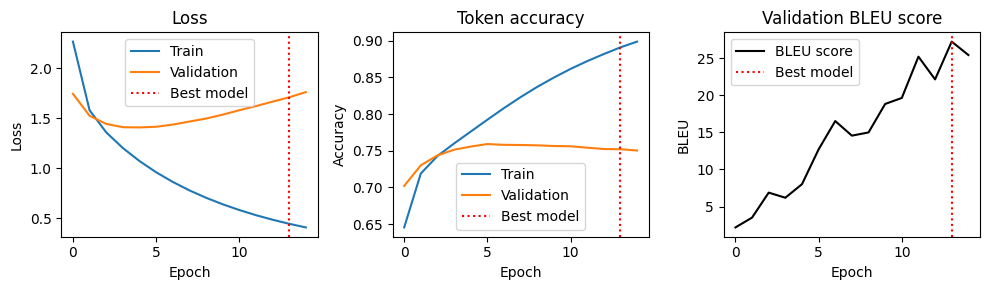

In [12]:
# Plot learning curves: loss, accuracy, and BLEU
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Epoch where best BLEU was achieved (model weights restored from here)
best_epoch = bleu_callback.best_epoch

# Left plot: training vs validation loss
# Overfitting visible when validation loss increases while training loss decreases
axes[0].set_title('Loss')
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')

# Middle plot: token-level accuracy
# Shows fraction of correctly predicted tokens (inflated by padding tokens)
axes[1].set_title('Token accuracy')
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

# Right plot: BLEU score over training
# Marker shows best checkpoint (weights restored from this epoch)
axes[2].set_title('Validation BLEU score')
axes[2].plot(bleu_callback.bleu_scores, c='black', label='BLEU score')
axes[2].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

**Note:** The loss and accuracy curves show clear overfitting (validation plateaus while training improves), yet BLEU continues to increase. Why?

- **Loss/accuracy** are computed using **teacher forcing** - the model sees ground truth previous tokens
- **BLEU** evaluates **autoregressive generation** - the model sees its own predictions

These are fundamentally different tasks. A model can memorize training sequences (overfitting the teacher-forcing objective) while its ability to generate coherent translations continues improving as embeddings become richer and general translation patterns solidify.

## 4. Translation examples and detailed evaluation

For inference, we split the model into separate encoder and decoder models. The encoder runs once to produce the initial states, then the decoder runs autoregressively, feeding each predicted token back as input.

**Inference architecture:**

```text

  STEP 1: Encode (run once)                     STEP 2: Decode token by token

  Input: "Hello world"                                 ┌─────────────┐
          │                           t=0: <pad> ─────►│  Embedding  │
          ▼                                            └──────┬──────┘
   ┌─────────────┐                                            │
   │  Embedding  │                                            ▼
   └──────┬──────┘                                     ┌─────────────┐
          │                           [h₀,c₀] ────────►│    LSTM     │───► [h₁,c₁]
          ▼                                            └──────┬──────┘
  ┌───────────────┐                                           │
  │ Bidirectional │                                           ▼
  │     LSTM      │                                    ┌─────────────┐
  └───────┬───────┘                                    │   Dense     │───► "Bonjour"
          │                                            └─────────────┘
          ▼
      [h₀, c₀]

  t=0: <pad>     ──► Embedding ──► LSTM ──► Dense ──► "Bonjour" (using h₀,c₀)
  t=1: "Bonjour" ──► Embedding ──► LSTM ──► Dense ──► "monde"   (using h₁,c₁)
  t=2: "monde"   ──► Embedding ──► LSTM ──► Dense ──► </s>      (stop)
```

The decoder model takes one token at a time and outputs the next token prediction plus updated states. We repeat until the model outputs an end-of-sequence token or reaches the maximum length.

In [13]:
# Build final inference models for translation examples
encoder_model, decoder_model = build_inference_models(model, latent_dim=256)

# Test translation on sample sentences
test_sentences = [
    'Hello, how are you?',
    'I love programming.',
    'The weather is nice today.'
]

print('Sample translations:')

for sent in test_sentences:

    print(f'  EN: {sent}')
    print(f'  FR: {translate(sent, encoder_model, decoder_model)}\n')

Sample translations:
  EN: Hello, how are you?
  FR: Salut, comment vous voulez ?

  EN: I love programming.
  FR: J'aimlé la prière.

  EN: The weather is nice today.
  FR: C'est le moment de tout le monde.



### 4.1. Evaluate translations

In [14]:
# Evaluate on a larger sample than used during training callback
np.random.seed(315)
sample_indices = np.random.choice(len(pairs), size=min(200, len(pairs)), replace=False)

# Collect model predictions and ground truth
hypotheses = []  # Model translations
references = []  # Ground truth translations

print('Generating translations for BLEU evaluation...')

for i, idx in enumerate(sample_indices):

    en_text, fr_ref = pairs[idx]
    fr_hyp = translate(en_text, encoder_model, decoder_model)
    
    hypotheses.append(fr_hyp)
    references.append(fr_ref)
    
    # Progress indicator
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(sample_indices)} samples')

# Compute corpus-level BLEU (aggregates n-gram precision across all sentences)
bleu = BLEU()
result = bleu.corpus_score(hypotheses, [references])

print(f'\nBLEU score: {result.score:.2f}')
print(f'Breakdown: {result}')

# Qualitative analysis: inspect individual translations
print('\nSample predictions vs references:')
for i in range(5):

    print(f'  Source: {pairs[sample_indices[i]][0]}')
    print(f'  Reference: {references[i]}')
    print(f'  Hypothesis: {hypotheses[i]}\n')

Generating translations for BLEU evaluation...
  Processed 50/200 samples
  Processed 100/200 samples
  Processed 150/200 samples
  Processed 200/200 samples

BLEU score: 27.85
Breakdown: BLEU = 27.85 54.7/31.4/22.4/17.2 (BP = 0.976 ratio = 0.977 hyp_len = 1215 ref_len = 1244)

Sample predictions vs references:
  Source: - Your daughter.
  Reference: Votre fille.
  Hypothesis: - Votre fille.

  Source: - I'm doing it for you!
  Reference: Il faut que tu en parles à tes parents.
  Hypothesis: - Je fais de l'avance !

  Source: http://www.eclaireurs.org
  Reference: http://scouts.montigny.free.fr
  Hypothesis: http://www.forward-app-equi.org/

  Source: Are you deaf? !
  Reference: T'es sourde ?
  Hypothesis: T'es sous-mar ?

  Source: My poorfellow, it seems we aren't much different.
  Reference: Nous sommes logés à la même enseigne, mon vieux.
  Hypothesis: Nous sommes bien plus à choix, tu le sais.

